## Анализ данных

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

In [3]:
df = pd.read_csv('recsys_course/interactions.csv').iloc[:-1]
df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [4]:
df.count()

user_id          5476250
item_id          5476250
last_watch_dt    5476250
total_dur        5476250
watched_pct      5475422
dtype: int64

In [9]:
print("Пропуски:\n", df.isna().sum())

Пропуски:
 user_id            0
item_id            0
last_watch_dt      0
total_dur          0
watched_pct      828
week               0
dtype: int64


In [5]:
stats = df[['total_dur', 'watched_pct']].describe()

In [6]:
print(stats.round(2))

         total_dur  watched_pct
count   5476250.00   5475422.00
mean       8295.49        46.37
std       48568.00        41.92
min           1.00         0.00
25%         371.00         4.00
50%        2898.00        32.00
75%        7116.00       100.00
max    80411672.00       100.00


In [7]:
min_date = df['last_watch_dt'].min()
max_date = df['last_watch_dt'].max()

print(f"Начало: {min_date}")
print(f"Конец: {max_date}")

Начало: 2021-03-13
Конец: 2021-08-22


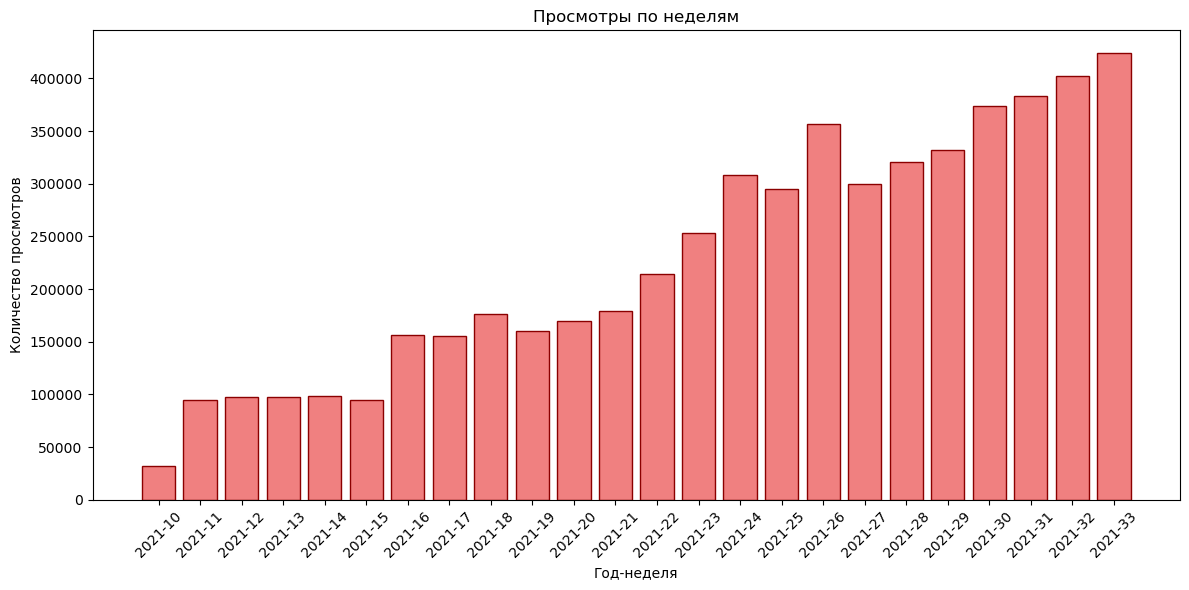

In [8]:
df['last_watch_dt'] = pd.to_datetime(df['last_watch_dt'])
df['week'] = df['last_watch_dt'].dt.strftime('%Y-%W')

weekly_views = df.groupby('week').size().reset_index(name='views_count')

plt.figure(figsize=(12, 6))
plt.bar(weekly_views['week'], 
        weekly_views['views_count'],
        color='lightcoral',
        edgecolor='darkred')

plt.title('Просмотры по неделям')
plt.xlabel('Год-неделя')
plt.ylabel('Количество просмотров')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df['last_watch_dt'] = (pd.to_datetime(df['last_watch_dt']) - pd.to_datetime(df['last_watch_dt']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
4299044,892649,7787,140,957,17.0
4725492,28478,14431,160,24936,100.0
4687425,892594,15297,116,2,0.0
180224,24024,6162,156,1697,30.0
285031,847209,6774,72,5989,97.0


In [8]:
stats = df[['last_watch_dt']].describe()

In [9]:
print(stats.round(2))

       last_watch_dt
count     5476250.00
mean          102.50
std            42.82
min             0.00
25%            73.00
50%           110.00
75%           139.00
max           162.00


График распределения популярности

In [9]:
popular_plot = df.item_id.value_counts(True).cumsum().reset_index().reset_index()

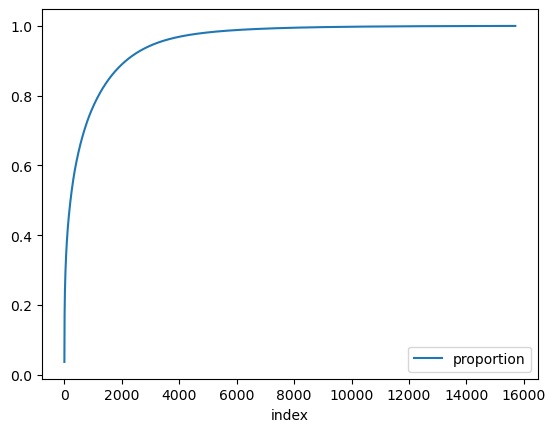

In [10]:
popular_plot.plot(x='index', y='proportion')
plt.show()

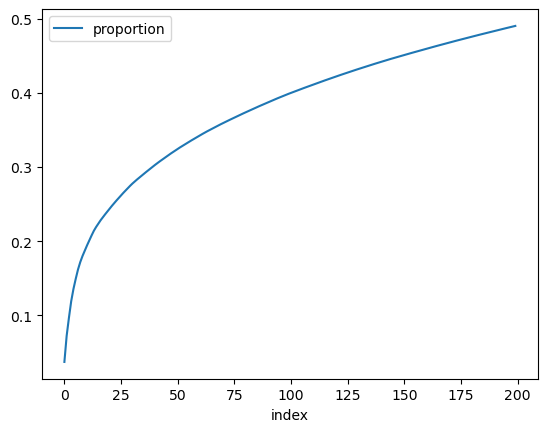

In [11]:
popular_plot[:200].plot(x='index', y='proportion')
plt.show()

Сделаем разбиение по времени

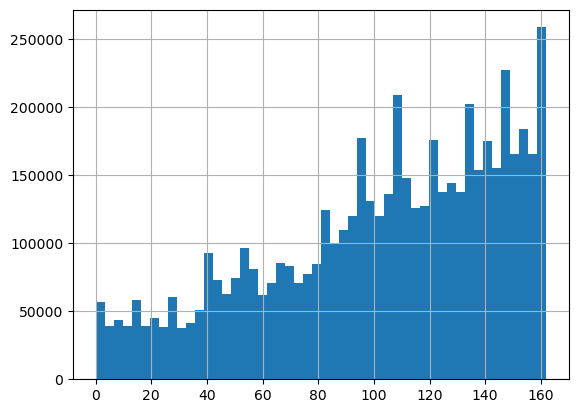

In [12]:
df.last_watch_dt.hist(bins=50)
plt.show()

## train/test

In [13]:
train_df = df.loc[(df.last_watch_dt < 160-7)].copy()
test_df = df.loc[(df.last_watch_dt >= 160-7)].copy()

train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  134670
число людей всего: 880449


In [14]:
len(set(test_users) - set(train_users)) / len(test_users)

0.37768022181146027

И переведём всё к соединённому датасету:

In [10]:
n_users = 10000

all_included = np.random.choice(all_included, size=n_users, replace=False)

train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()
test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert train_df.user_id.nunique() == n_users
assert test_df.user_id.nunique() == n_users

In [11]:
train_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
33,68478,9728,151,139,2.0
47,163922,1931,45,155,0.0
49,474544,10440,95,36469,90.0
56,580093,15411,151,10479,100.0
104,570761,9550,90,31738,100.0


In [12]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

C:\Users\isem2\AppData\Local\Temp\ipykernel_5456\1105526701.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_grouped = train_df.groupby('user_id').apply(
C:\Users\isem2\AppData\Local\Temp\ipykernel_5456\1105526701.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_grouped = test_df.groupby('user_id').apply(


,user_id,train_interactions
0,55,"[(9896, 15), (6192, 60), (3076, 99), (15297, 1..."
1,179,"[(14, 75), (13865, 95), (10440, 95), (9728, 97)]"
2,229,"[(11275, 110), (4151, 110), (1699, 126), (1460..."
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399..."
4,448,"[(142, 95), (2256, 102), (13865, 104), (15297,..."


In [13]:
joined = train_grouped.merge(test_grouped)
joined.head()

,user_id,train_interactions,test_interactions
0,21,"[(10283, 7), (15997, 15), (12261, 17), (4345, ...","[(12360, 155), (13787, 158), (14488, 158)]"
1,30,"[(4740, 88), (676, 91), (12418, 98), (9728, 10...","[(15363, 153), (11253, 153), (1107, 154), (234..."
2,144,"[(9728, 126), (13865, 128), (741, 130), (15297...","[(4151, 155), (10942, 157), (8821, 157), (3734..."
3,157,"[(10440, 142), (15297, 143), (4713, 151), (124...","[(16228, 156), (2616, 160)]"
4,175,"[(13865, 100), (9728, 109), (10440, 117), (128...","[(15297, 153)]"


In [14]:
np.random.seed(777)

class Random:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        items = set()
        for _, row in df.iterrows():
            for item, _ in row[col]:
                items.add(item)

        self.items = list(items)
        self.trained = True

    def predict(self, df, topn=10):
        assert self.trained
        return [np.random.choice(self.items, replace=False, size=topn)]*len(df)


random = Random()
random.fit(joined)

joined['random_recs'] = random.predict(joined, topn=3)
joined.head()

,user_id,train_interactions,test_interactions,random_recs
0,21,"[(10283, 7), (15997, 15), (12261, 17), (4345, ...","[(12360, 155), (13787, 158), (14488, 158)]","[10910, 11668, 5479]"
1,30,"[(4740, 88), (676, 91), (12418, 98), (9728, 10...","[(15363, 153), (11253, 153), (1107, 154), (234...","[10910, 11668, 5479]"
2,144,"[(9728, 126), (13865, 128), (741, 130), (15297...","[(4151, 155), (10942, 157), (8821, 157), (3734...","[10910, 11668, 5479]"
3,157,"[(10440, 142), (15297, 143), (4713, 151), (124...","[(16228, 156), (2616, 160)]","[10910, 11668, 5479]"
4,175,"[(13865, 100), (9728, 109), (10440, 117), (128...","[(15297, 153)]","[10910, 11668, 5479]"
